## About
this way the autoencoder works somehow but the shape it learned is poor quality and it just does not fit even though it finds outliers similarly to linear model or ML algorithms

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
#import mlflow

from anomaly_detection.utils.plotting_styles import apply_global_style

## Load data

In [2]:
from anomaly_detection.utils.load_sam_data import load_dataset
from anomaly_detection.utils.preprocess import drop_empty_histograms
from anomaly_detection.utils.preprocess import minmax_scale_per_sample

dataset = load_dataset("FJ")
full_dataset = np.array(dataset)
full_dataset = minmax_scale_per_sample(full_dataset)

dataset_no_outs = drop_empty_histograms(full_dataset)

Loading data from: C:\Users\hrdyj\coding\vyzkumak\data\FJ\FI01X1\FI01X1_ch
Dropped indexes [8, 15, 188, 214, 263, 268, 533, 546]


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(dataset_no_outs, shuffle=True, train_size=0.8, random_state=42)

In [4]:
dataset_no_outs = torch.from_numpy(dataset_no_outs)
X_train = torch.from_numpy(X_train)
X_test = torch.from_numpy(X_test)
full_dataset = torch.from_numpy(full_dataset)

dataset_no_outs = dataset_no_outs.to(torch.float32)
X_train = X_train.to(torch.float32)
X_test = X_test.to(torch.float32)
full_dataset = full_dataset.to(torch.float32)

## Define model

In [ ]:
import torch.nn as nn

class AE_low(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 4, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(4),
            nn.ReLU(),

            nn.Conv1d(4, 6, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(6),
            nn.ReLU(),

            nn.Conv1d(6, 8, kernel_size=2, stride=2),
            nn.BatchNorm1d(8),
            nn.ReLU(),

            nn.Conv1d(8, 10, kernel_size=6, stride=1),
            nn.BatchNorm1d(10), # tady mozna odstranit BN
            nn.Sigmoid(),
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(10, 8, kernel_size=6, stride=1),
            nn.BatchNorm1d(8),
            nn.ReLU(),

            nn.ConvTranspose1d(8, 6, kernel_size=2, stride=2),
            nn.BatchNorm1d(6),
            nn.ReLU(),

            nn.ConvTranspose1d(6, 4, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(4),
            nn.ReLU(),

            nn.ConvTranspose1d(4, 1, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm1d(1),
            nn.Sigmoid()
        )

    
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# Set up mlflow tracking

1. start server
- this will create a sqlite database in the current directory (if not present)
```bash
mlflow server --host 127.0.0.1 --port 5000
```

2. set tracking uri
- this will connect the mlflow client to the server
```python
mlflow.set_tracking_uri("http://127.0.0.1:5000")
```

3. set experiment name
- this will create a new experiment in the server
```python
mlflow.set_experiment(experiment_name)
```

In [58]:
pt = full_dataset[0].reshape(1, 1, 96)
model = AE_low()
print("Embedding shape:",model.encoder(pt.reshape(1,1,96)).shape)

Embedding shape: torch.Size([1, 10, 7])


In [59]:
# mlflow.set_tracking_uri("http://127.0.0.1:5000")
# experiment_name = "anomaly_detection/autoencoders"
# mlflow.set_experiment(experiment_name)
# run_name = "ae_mlp_v1.1_Wass_Reg"

## Train model

In [60]:
from torch.utils.data import DataLoader
from anomaly_detection.utils.autoencoders import HistDataset
from anomaly_detection.utils.losses import Wasserstein1DLoss

batch_size = 32
train_dataset = HistDataset(X_train)
test_dataset = HistDataset(X_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

criterion = Wasserstein1DLoss()
lam = 10e-4

model = AE_low()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.0005)

In [61]:
from anomaly_detection.utils.autoencoders import train_ae

#with mlflow.start_run(run_name=run_name):
train_losses, val_losses, ae_conv = train_ae(n_epochs=250, 
                                             dataloader=train_loader, 
                                             model=model, 
                                             val_loader=test_loader, 
                                             optimizer=optimizer, 
                                             criterion=criterion,
                                             add_regularization=True,
                                             lam=lam,
                                             save_checkpoints=False,
                                             saving_after_epoch=20,
                                             model_name="ae_conv_v3.1_Wass_Reg",
                                             input_dim=96,
                                             latent_dim=24)

Ep [0 / 250]: Train loss 10.211418211460114 | test loss 10.701921939849854
Ep [25 / 250]: Train loss 1.1702274628465794 | test loss 1.0896331369876862
Ep [50 / 250]: Train loss 0.7588654425884995 | test loss 0.7458737790584564
Ep [75 / 250]: Train loss 0.6211699910997577 | test loss 0.6590477898716927
Ep [100 / 250]: Train loss 0.5252244492190836 | test loss 0.5898164808750153
Ep [125 / 250]: Train loss 0.4673729847978239 | test loss 0.5251102522015572
Ep [150 / 250]: Train loss 0.42365418028217555 | test loss 0.502088226377964
Ep [175 / 250]: Train loss 0.3934082197161206 | test loss 0.464537363499403
Ep [200 / 250]: Train loss 0.3793916049979155 | test loss 0.4517621584236622
Ep [225 / 250]: Train loss 0.36757802807542406 | test loss 0.4323032647371292


## Plot metrics

- or visit http://127.0.0.1:5000 to see the metrics

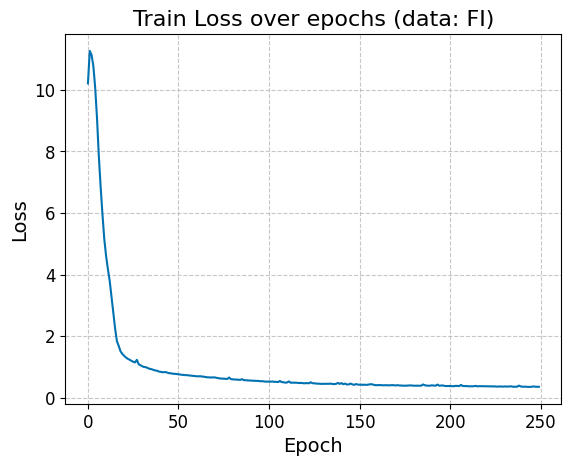

In [62]:
apply_global_style()
plt.title("Train Loss over epochs (data: FI)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(range(len(train_losses)), train_losses)
plt.show()

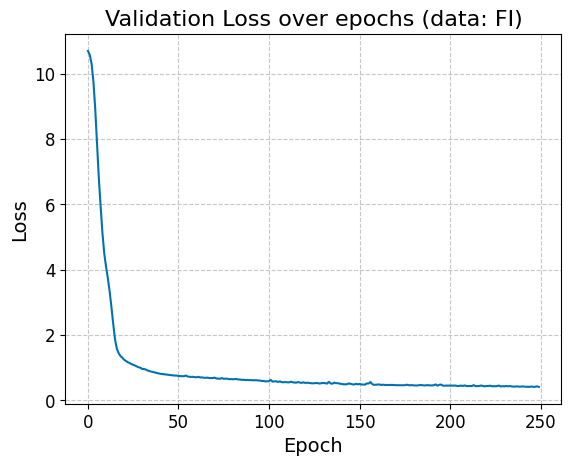

In [63]:
apply_global_style()
plt.title("Validation Loss over epochs (data: FI)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(range(len(val_losses)), val_losses)
plt.show()

In [64]:
full_dataset = HistDataset(full_dataset)

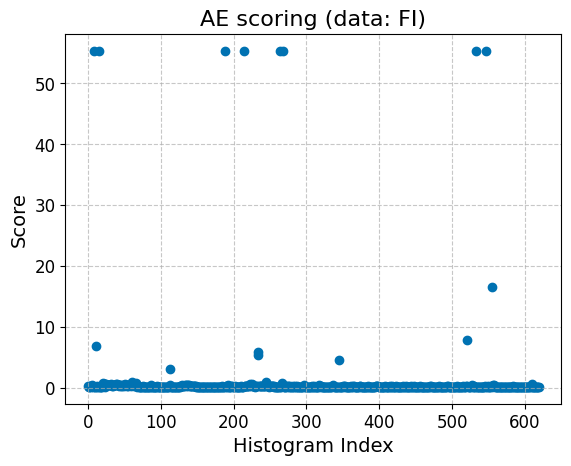

In [65]:
apply_global_style()
plt.title("AE scoring (data: FI)")
plt.xlabel("Histogram Index")
plt.ylabel("Score")

model.eval()
score = []

with torch.no_grad():
    for pt in full_dataset:
        pred = model(pt.reshape(1,1,96))
        loss = criterion(pred, pt).detach().numpy()
        score.append(loss)

plt.scatter(range(len(score)), score)
plt.show()

In [66]:
outliers = np.where(np.array(score) > 45)
outliers

(array([  8,  15, 188, 214, 263, 268, 533, 546]),)

In [67]:
import numpy as np

preds = []

with torch.no_grad():
    for idx, data in enumerate(full_dataset):
        pred = model(data.reshape(1, 1, 96)).cpu().numpy().squeeze()
        
        for p in preds:
            if np.array_equal(pred, p):
                break
        else:
            preds.append(pred)

print(f"There are {len(preds)} unique representations that model outputs")

There are 613 unique representations that model outputs


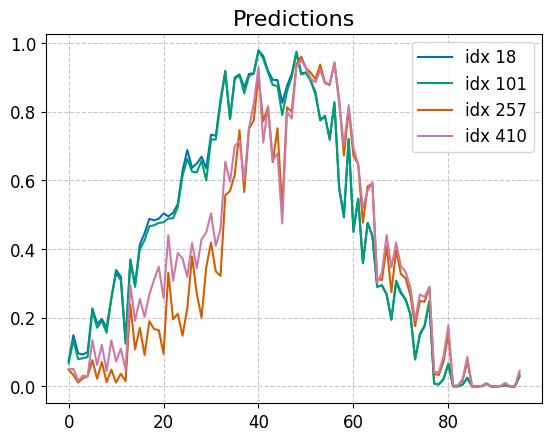

In [68]:
def plot_selected(preds, indices):
    if len(indices) != 4:
        raise ValueError("Exactly 4 indices must be provided.")

    if isinstance(preds, torch.Tensor):
        preds = preds.detach().cpu().numpy()

    preds = np.asarray(preds)

    if preds.ndim == 1:
        values = preds[indices]

        plt.figure()
        plt.bar(range(4), values)
        plt.xticks(range(4), indices)
        plt.title("Selected indices")
        plt.show()

    elif preds.ndim >= 2:
        plt.figure()
        for idx in indices:
            plt.plot(preds[idx], label=f"idx {idx}")

        plt.legend()
        plt.title("Predictions")
        apply_global_style()
        plt.show()

    else:
        raise ValueError("Unsupported tensor shape.")

plot_selected(preds, [18, 101, 257, 410])

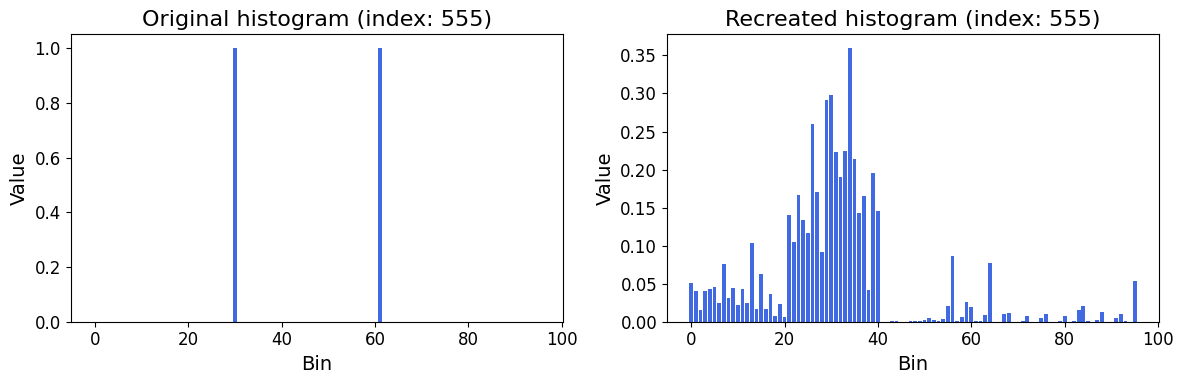

In [74]:
from anomaly_detection.utils.inspect_hist import plot_original_and_reconstructed

plot_original_and_reconstructed(model, full_dataset, idx=555)

In [70]:
score_dict = {idx : s for idx, s in enumerate(score)}
indexes_sorted_by_score = sorted(score_dict, key=lambda x: score_dict[x], reverse=True)

print("highest scores", indexes_sorted_by_score[:10] )
print("lowest scores", indexes_sorted_by_score[-3:])

highest scores [8, 15, 188, 214, 263, 268, 533, 546, 555, 520]
lowest scores [559, 167, 462]


In [75]:
from anomaly_detection.config.paths import CHECKPOINT_DIR

save_model = True

if save_model:
    torch.save({
        "model_state_dict": ae_conv.state_dict(),
        "config": {
            "input_dim": 96,
            "latent_dim": 7,
            "num_latent_space_embeddings" : 10
        }
    }, f"{CHECKPOINT_DIR}/SVDD_v1.pth")